# Breast Cancer Risk Prediction  
### 10-Year Mortality Prediction using Machine Learning & Survival Analysis

This project focuses on predicting the 10-year mortality risk of breast cancer patients using clinical features from the METABRIC dataset. The objective is to support treatment planning, and clinical decision-making by combining machine learning classification models with survival analysis techniques.


In [1]:
#from google.colab import files
#files.upload()

In [2]:
# Import core libraries for data manipulation, visualization, and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold ,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score

In [ ]:
# Data Loading
data=pd.read_csv("Breast Cancer METABRIC(in).csv")
data.head(3)

In [4]:
data.shape

(2509, 34)

In [ ]:
# Initial Data Inspection
data.isnull().sum()

In [6]:
# Correcting Inconsistent Category Values Some categorical values had spelling inconsistencies
data['ER status measured by IHC'] = data['ER status measured by IHC'].replace(
    {'Positve': 'Positive'})

In [7]:
# Rows with missing overall survival or vital status were removed, as these fields are essential for creating the target variable.

data = data.dropna(
    subset=["Overall Survival (Months)", "Patient's Vital Status"])

Target Variable: 10_year_mortality

1 → Patient died within 10 years

0 → Patient survived beyond 10 years

Created using overall survival months and vital status

In [8]:
# Creating Target Variable: 10-Year Mortality
data['10_year_mortality'] = data.apply(
    lambda row: 1
    if (row["Patient's Vital Status"] == "Died of Disease"
        and row["Overall Survival (Months)"] <= 120)
    else 0,
    axis=1)

In [9]:
data['10_year_mortality'].value_counts()

,count
10_year_mortality,
0,1465
1,515


In [ ]:
# Handling Numerical Missing Values
num_cols = [
    'Age at Diagnosis',
    'Tumor Size',
    'Tumor Stage',
    'Lymph nodes examined positive',
    'Neoplasm Histologic Grade'
]

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

Numerical features were imputed using the median because it is robust to outliers.

In [ ]:
# Handling Categorical Missing Values
cat_cols = [
    'Type of Breast Surgery',
    'Cancer Type Detailed',
    'Cellularity',
    'Chemotherapy',
    'ER status measured by IHC',
    'HER2 Status',
    'Hormone Therapy',
    'PR Status',
    'Radio Therapy'
]

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

Categorical features were imputed using the mode since it preserves the most frequent category without creating unrealistic values.

## Exploratory Data Analysis (EDA)
EDA was performed to understand the relationship between clinical features and 10-year mortality and to support feature selection.


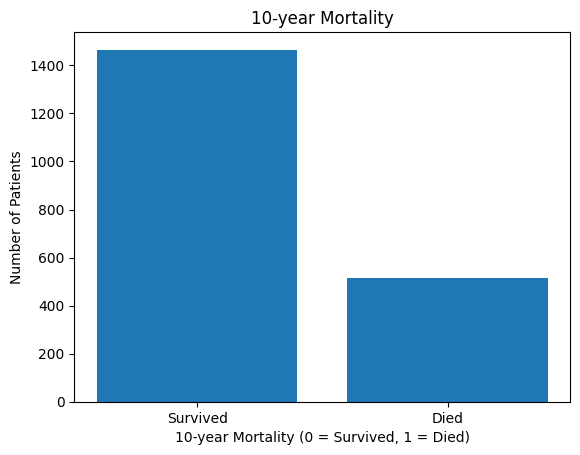

In [12]:
# 10-year Mortality Distribution
counts=data['10_year_mortality'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel("10-year Mortality (0 = Survived, 1 = Died)")
plt.ylabel("Number of Patients")
plt.title("10-year Mortality")
plt.xticks(counts.index, ['Survived', 'Died'])
plt.show()

Most patients survived, and fewer patients died, so the dataset is imbalanced. That’s why accuracy alone is not enough.

In [13]:
data['age group']=pd.cut(data['Age at Diagnosis'],bins=[20,40,60,80,100],labels=['20–40', '40–60', '60–80', '80+'],right=False)

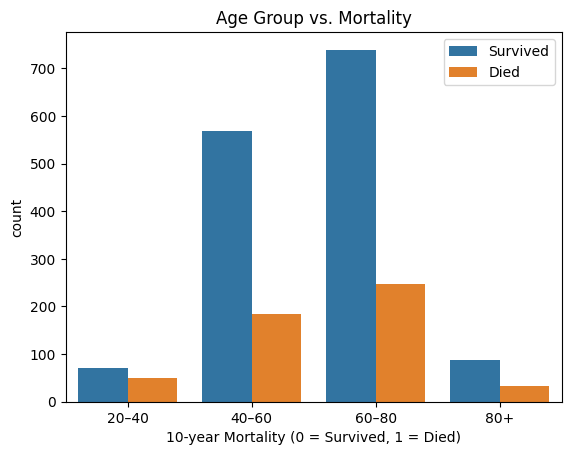

In [14]:
# Age Group vs Mortality
sns.countplot(x='age group',hue='10_year_mortality',data=data)
plt.title("Age Group vs. Mortality")
plt.xlabel("10-year Mortality (0 = Survived, 1 = Died)")
plt.legend(['Survived', 'Died'])
plt.show()

Older age groups show a higher proportion of deaths, which confirms that age is an important predictor.

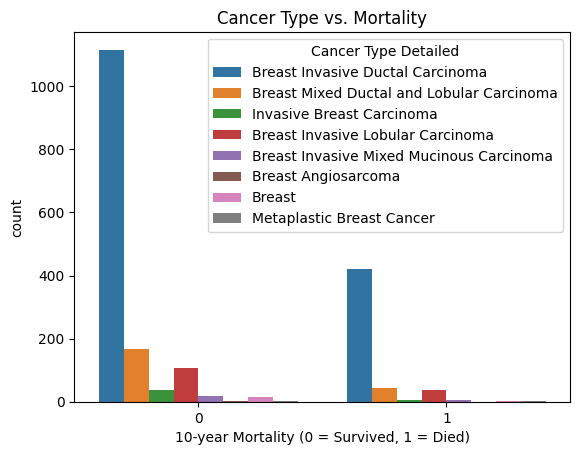

In [15]:
# Cancer Type vs Mortality
sns.countplot(x='10_year_mortality', hue='Cancer Type Detailed', data=data)
plt.title("Cancer Type vs. Mortality")
plt.xlabel("10-year Mortality (0 = Survived, 1 = Died)")
plt.show()

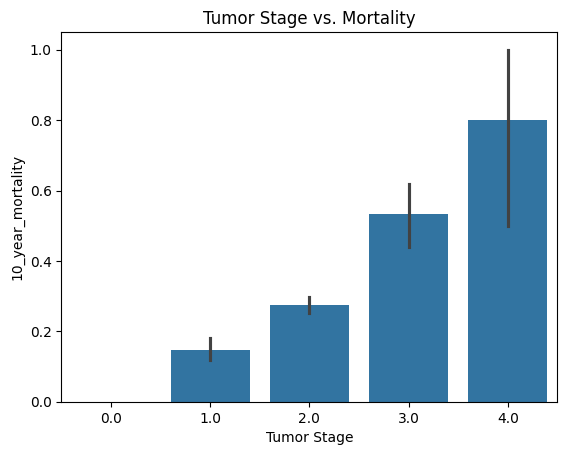

In [16]:
# Tumor Stage vs Mortality
sns.barplot(x='Tumor Stage', y='10_year_mortality', data=data)
plt.title("Tumor Stage vs. Mortality")
plt.xlabel("Tumor Stage")
plt.show()

As tumor stage increases, the proportion of deaths increases, showing that advanced cancer stages have worse outcomes.

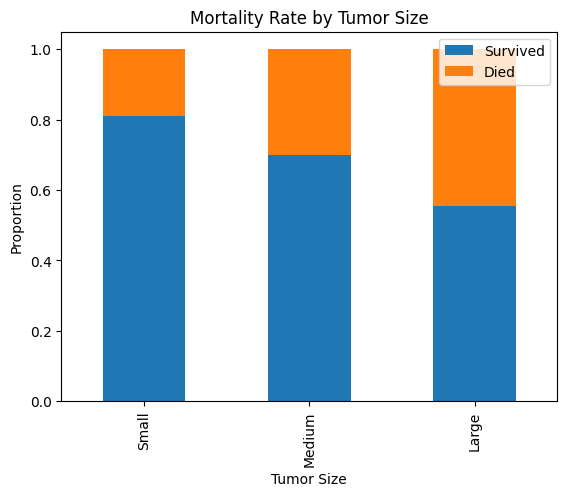

In [17]:
# Mortality Rate by Tumor Size
data['Tumor_Size_Group'] = pd.cut(data['Tumor Size'],bins=[0, 20, 50, 200],
    labels=['Small', 'Medium', 'Large'])

size_mortality = pd.crosstab(data['Tumor_Size_Group'],data['10_year_mortality'],normalize='index')

size_mortality.plot(kind='bar', stacked=True)
plt.title("Mortality Rate by Tumor Size")
plt.ylabel("Proportion")
plt.xlabel("Tumor Size")
plt.legend(['Survived', 'Died'])
plt.show()

Patients with larger tumors have a higher death rate, which supports using tumor size as an input feature.

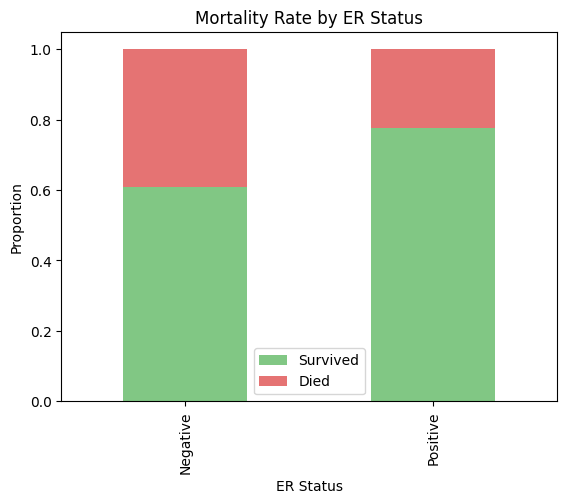

In [18]:
# Mortality Rate by ER Status
er_mortality = pd.crosstab(
    data['ER status measured by IHC'],data['10_year_mortality'],normalize='index')

er_mortality.plot(kind='bar', stacked=True,color=['#81C784', '#E57373'])
plt.title("Mortality Rate by ER Status")
plt.ylabel("Proportion")
plt.xlabel("ER Status")
plt.legend(['Survived', 'Died'])
plt.show()

ER-negative patients show a higher proportion of deaths compared to ER-positive patients, indicating ER status is an important predictor of survival.



In [ ]:
!pip install lifelines

## Survival Analysis using Kaplan–Meier Estimator

In [20]:
from lifelines import KaplanMeierFitter

In [21]:
data['event'] = data["Patient's Vital Status"].apply(
    lambda x: 1 if x == 'Died of Disease' else 0)

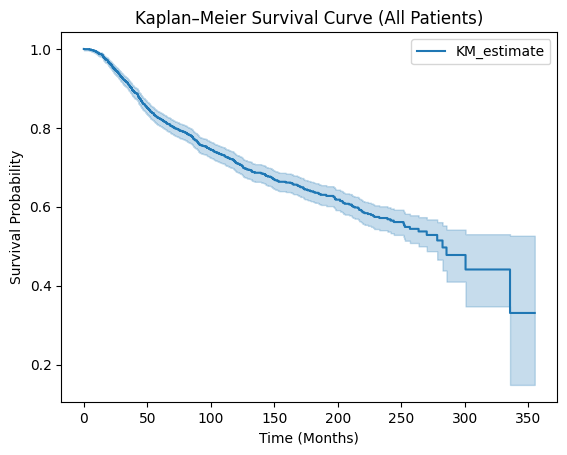

In [22]:
kmf = KaplanMeierFitter()

kmf.fit(durations=data['Overall Survival (Months)'],
        event_observed=data['event'])

kmf.plot()
plt.title("Kaplan–Meier Survival Curve (All Patients)")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.show()

The Kaplan–Meier curve shows how the probability of patients surviving decreases over time. Each drop in the curve represents a death event, and the curve gradually declines as time progresses.

ML tells who is high-risk

Kaplan–Meier tells how survival changes over time

Kaplan–Meier analysis was used to estimate survival probability over time and visualize long-term survival patterns of breast cancer patients.

Survival analysis complements machine learning by providing time-dependent insights rather than a single binary outcome.

In [23]:
#Creating X and Y variable
x = data[[
    'Age at Diagnosis',
    'Type of Breast Surgery',
    'Cancer Type Detailed',
    'Cellularity',
    'Chemotherapy',
    'ER status measured by IHC',
    'Neoplasm Histologic Grade',
    'HER2 Status',
    'Hormone Therapy',
    'Lymph nodes examined positive',
    'PR Status',
    'Radio Therapy',
    'Tumor Size',
    'Tumor Stage']]

y = data['10_year_mortality']

In [24]:
#Made a copy of x to ensure that changes are applied safely to our dataset and to avoid pandas assignment warnings.
x=x.copy()

In [ ]:
x.dtypes

# Feature Encoding

In [26]:
# Encoding Binary Variables
binary_cols = [
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    'ER status measured by IHC',
    'PR Status',
    'HER2 Status']

binary_map = {'Yes': 1, 'No': 0, 'Positive': 1, 'Negative': 0}

for col in binary_cols:
    x.loc[:, col] = x[col].map(binary_map)

Used for: Yes/No, Positive/Negative

In [27]:
# Encoding Cellularity
x.loc[:,'Cellularity'] = x['Cellularity'].map({
    'Low': 1,
    'Moderate': 2,
    'High': 3})

Used for: Ordered categories

Low < Medium < High


 1 < 2 < 3

In [28]:
# One-Hot Encoding Categorical Features
x = pd.get_dummies(x,columns=['Type of Breast Surgery', 'Cancer Type Detailed'],drop_first=True)

Used for: Categories with no order

drop_first=True removes one category to avoid giving the model repeated information and keeps the results easier to understand.

In [29]:
# Split data into train test
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=0,stratify=y)# Stratification ensures class imbalance is preserved

In [30]:
# Outlier detection on training data ONLY
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((x_train[col] < lower) | (x_train[col] > upper)).sum()
    print(f"{col}: {outliers} outliers")

Age at Diagnosis: 0 outliers
Neoplasm Histologic Grade: 0 outliers
Lymph nodes examined positive: 167 outliers
Tumor Size: 128 outliers
Tumor Stage: 8 outliers


### Outlier Analysis

Outliers were identified in numerical features using the IQR method on the training data.  
Several features such as lymph node involvement and tumor size showed a high number of outliers, which correspond to clinically severe cancer cases.  
In medical datasets, these extreme values are meaningful and removing them would eliminate high-risk patients and bias mortality prediction.  
Therefore, outliers were retained, and their influence was controlled using regularization instead of removal.

## Model Building


In [31]:
model = LogisticRegression(
    max_iter=1000,C=0.5,          # stronge regularization
    solver='liblinear')

model.fit(x_train,y_train)

LogisticRegression(C=0.5, max_iter=1000, solver='liblinear')

- **C = 0.5**: Prevents the model from becoming too complex by keeping feature weights small.
- **solver = 'liblinear'**: Calculates the best decision boundary between survived and died.
- **max_iter = 1000**: Gives the model enough chances to learn before stopping.


## Model Evaluation

In [32]:
y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)[:,1]

In [33]:
print("confusion matrix:",confusion_matrix(y_test,y_pred))

confusion matrix: [[281  12]
 [ 87  16]]


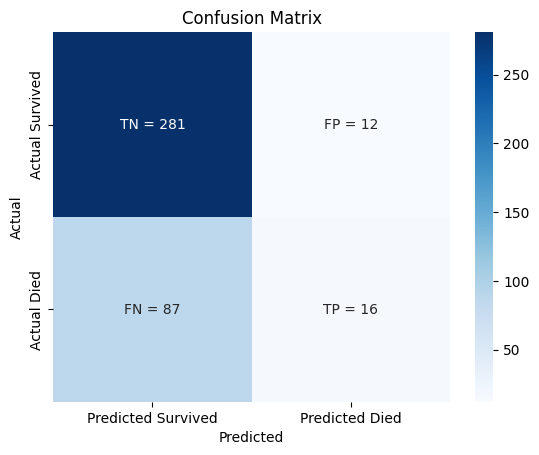

In [34]:
cm=np.array([[281, 12],
               [87, 16]])
labels = np.array([
    ["TN = 281", "FP = 12"],
    ["FN = 87",  "TP = 16"]])

sns.heatmap(cm, annot=labels, fmt="", cmap='Blues',
            xticklabels=["Predicted Survived", "Predicted Died"],
            yticklabels=["Actual Survived", "Actual Died"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

False Negatives (FN): Patients predicted to survive but actually died (most critical error)

False Positives (FP): Patients predicted to die but actually survived


In healthcare problems, false negatives are more critical than false positives because missing a high-risk patient can lead to delayed treatment.

## Threshold Adjustment

Logistic Regression uses 0.5 as default threshold

That means:Predict death only if probability ≥ 50%

The classification threshold was lowered to prioritize recall and reduce false negatives, which is critical in healthcare risk prediction

In [35]:
y_pred_40 = (y_prob >= 0.35).astype(int)
print(confusion_matrix(y_test, y_pred_40))

[[245  48]
 [ 57  46]]


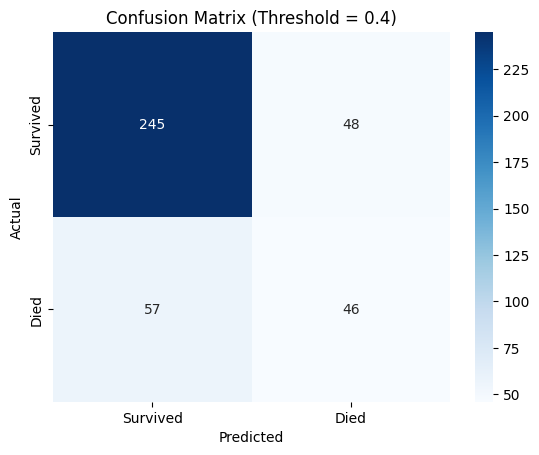

In [36]:
cm=[[245, 48],
 [ 57 ,46]]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title("Confusion Matrix (Threshold = 0.4)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
#ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)*100
print("ROC-AUC:", roc_auc)

ROC-AUC: 71.18194771198516


ROC-AUC was used to evaluate how well the model distinguishes between high-risk and low-risk patients across different thresholds.

In [38]:
#Accuracy
accuracy=accuracy_score(y_test,y_pred)*100
print("accuracy:",accuracy)

accuracy: 75.0


### Model Performance Discussion

The achieved accuracy and ROC-AUC are moderate due to class imbalance and overlapping clinical characteristics.
In real-world healthcare data, perfect separation between survival outcomes is rarely possible.
Therefore, performance was evaluated using clinically meaningful metrics rather than accuracy alone.


In [39]:
# Cross-validation to check over/underfitting

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='roc_auc')*100

print("CV ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())

CV ROC-AUC scores: [68.2044629  72.22106902 72.33549583 73.51971991 68.78257244]
Mean CV ROC-AUC: 71.01266401814729


Stratified folds controls how the data is split

cross_val_score uses those splits to train and evaluate the model.

I used ROC-AUC because the data is imbalanced and mortality prediction is sensitive to false negatives.


The model achieved consistent ROC-AUC scores across all folds, with a mean score of approximately 72.5%.

This indicates stable model performance and suggests that the model generalizes well without significant overfitting or underfitting.


In [ ]:
# Feature importance
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model.coef_[0]*100})

importance = importance.sort_values(by='Importance',key=abs,ascending=False)
importance.head(10)

In logistic regression, feature importance values (coefficients) mean direction of effect.

Positive value:- Increases the risk of death

Negative value:- Decreases the risk of death (more survival)

A negative coefficient does not mean the feature is unimportant; it means the feature is associated with better survival.

## Conclusion

This project demonstrates the application of machine learning and survival analysis to predict long-term mortality risk in breast cancer patients. The final model emphasizes interpretability and patient safety, making it suitable for real-world clinical decision support.
